In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("healthcare_dataset.csv")


In [3]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print("🧾 Column names:", df.columns.tolist())

🧾 Column names: ['name', 'age', 'gender', 'blood_type', 'medical_condition', 'date_of_admission', 'doctor', 'hospital', 'insurance_provider', 'billing_amount', 'room_number', 'admission_type', 'discharge_date', 'medication', 'test_results']


In [18]:
df.head()

,name,age,gender,blood_type,medical_condition,date_of_admission,doctor,hospital,insurance_provider,billing_amount,room_number,admission_type,discharge_date,medication,test_results
0,Tiffany Ramirez,81,Female,O-,Diabetes,17-11-2022,Patrick Parker,Wallace-Hamilton,Medicare,37490.98336,146,Elective,01-12-2022,Aspirin,Inconclusive
1,Ruben Burns,35,Male,O+,Asthma,01-06-2023,Diane Jackson,"Burke, Griffin and Cooper",UnitedHealthcare,47304.06485,404,Emergency,15-06-2023,Lipitor,Normal
2,Chad Byrd,61,Male,B-,Obesity,09-01-2019,Paul Baker,Walton LLC,Medicare,36874.89700,292,Emergency,08-02-2019,Lipitor,Normal
3,Antonio Frederick,49,Male,B-,Asthma,02-05-2020,Brian Chandler,Garcia Ltd,Medicare,23303.32209,480,Urgent,03-05-2020,Penicillin,Abnormal
4,Mrs. Brandy Flowers,51,Male,O-,Arthritis,09-07-2021,Dustin Griffin,"Jones, Brown and Murray",UnitedHealthcare,18086.34418,477,Urgent,02-08-2021,Paracetamol,Normal


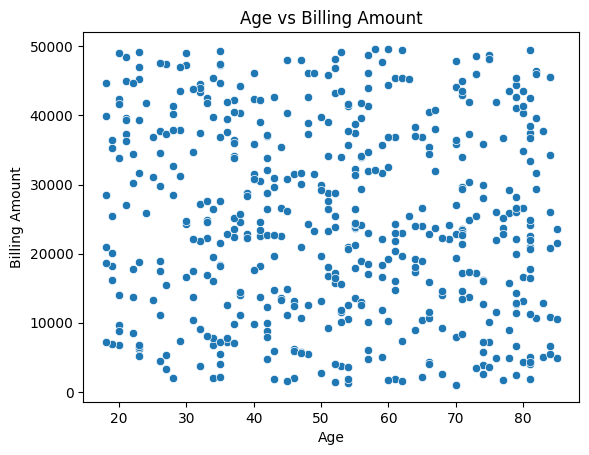

In [5]:
sns.scatterplot(data=df, x='age', y='billing_amount')
plt.title("Age vs Billing Amount")
plt.xlabel("Age")
plt.ylabel("Billing Amount")
plt.show()

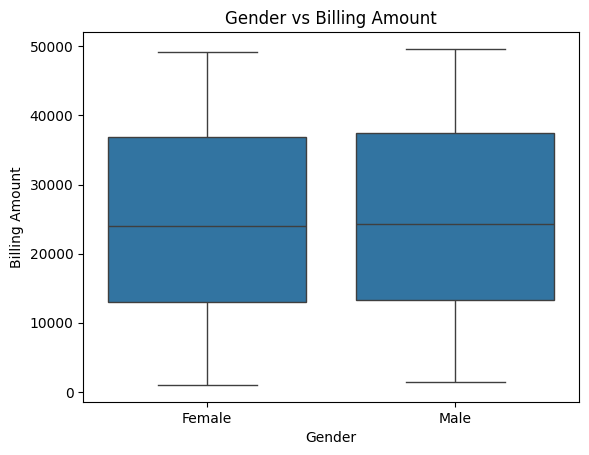

In [6]:
sns.boxplot(data=df, x='gender', y='billing_amount')
plt.title("Gender vs Billing Amount")
plt.xlabel("Gender")
plt.ylabel("Billing Amount")
plt.show()

Cross-tabulation:
 admission_type  Elective  Emergency  Urgent
gender                                     
Female                93         91      71
Male                  77         84      83


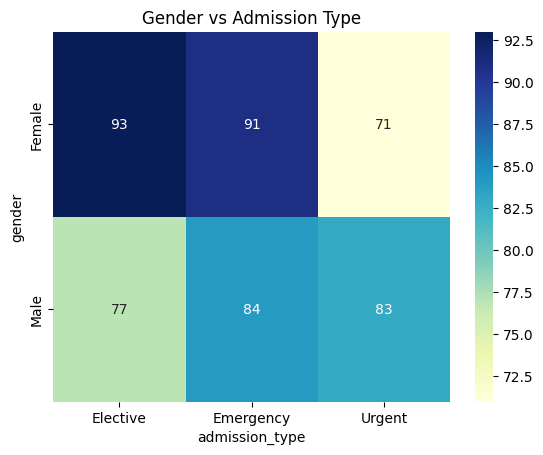

In [7]:
cross_tab = pd.crosstab(df['gender'], df['admission_type'])
print("Cross-tabulation:\n", cross_tab)

sns.heatmap(cross_tab, annot=True, cmap="YlGnBu")
plt.title("Gender vs Admission Type")
plt.show()


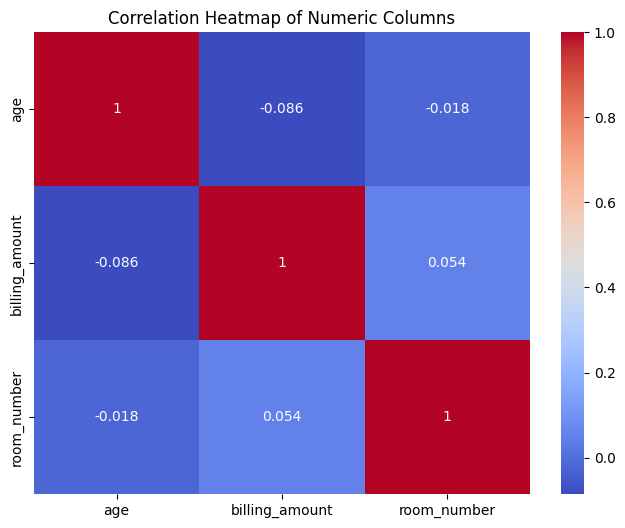

In [8]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numeric Columns")
plt.show()


C:\Users\RAJ JAISWAR\AppData\Local\Temp\ipykernel_23232\1962402744.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='gender', y='billing_amount', palette='Set2')


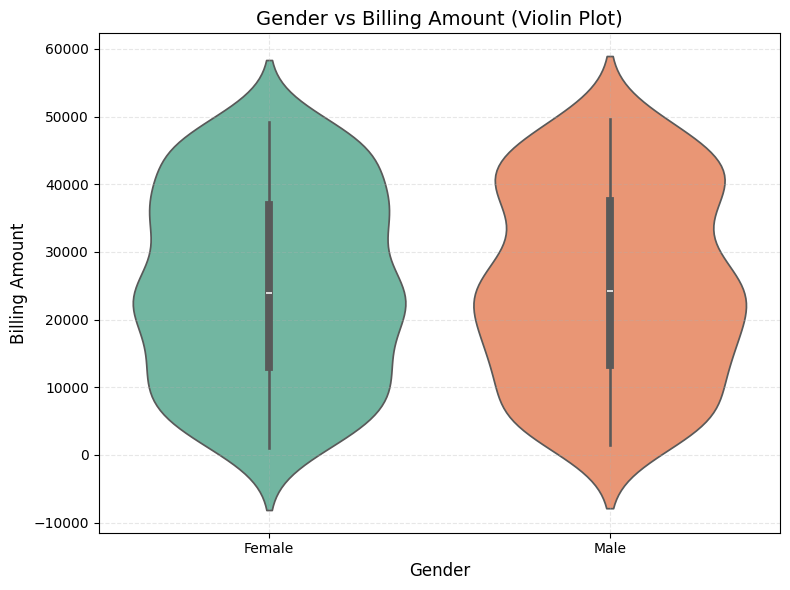

In [9]:
plt.figure(figsize=(8, 6))
sns.violinplot(data=df, x='gender', y='billing_amount', palette='Set2')
plt.title("Gender vs Billing Amount (Violin Plot)", fontsize=14)
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Billing Amount", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

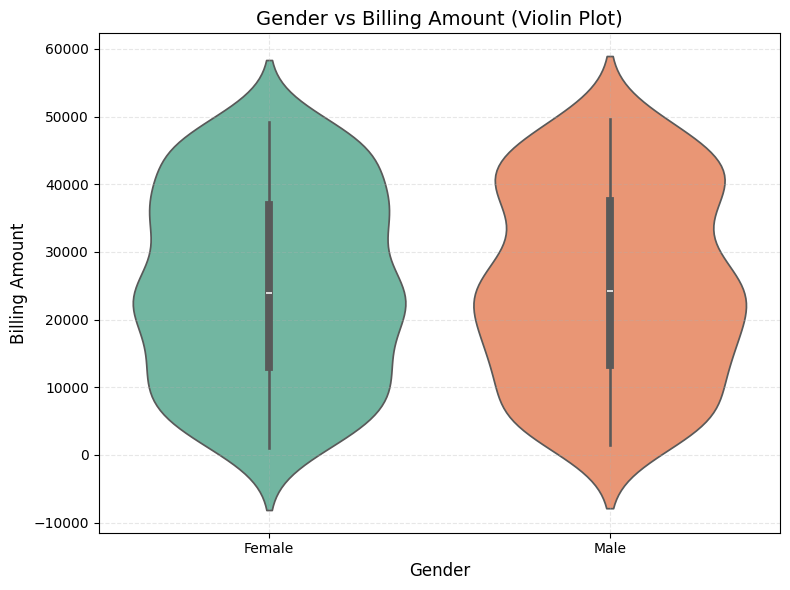

In [10]:
plt.figure(figsize=(8, 6))
sns.violinplot(data=df, x='gender', y='billing_amount', hue='gender', palette='Set2', legend=False)
plt.title("Gender vs Billing Amount (Violin Plot)", fontsize=14)
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Billing Amount", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
plt.figure()
sns.pairplot(data=df, vars=numerical_cols.columns, hue='gender', palette='Set2')
plt.suptitle("Pairwise Relationships (Colored by Gender)", y=1.02, fontsize=16)
plt.show()

NameError: name 'numerical_cols' is not defined

<Figure size 640x480 with 0 Axes>

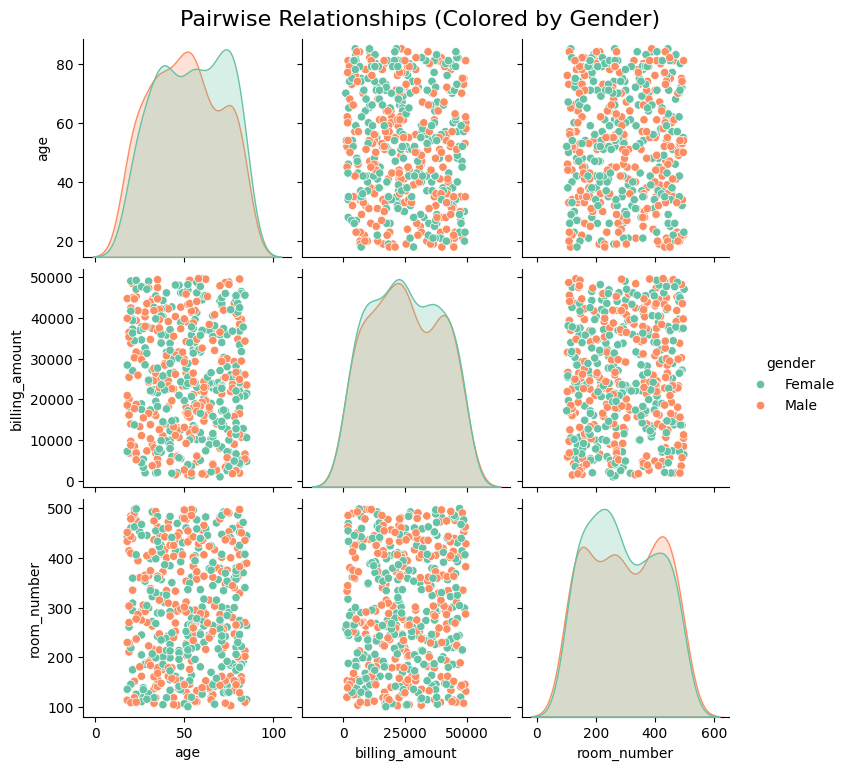

In [12]:
numerical_cols = df.select_dtypes(include='number').columns.tolist()

# ✅ Create the pairplot using the cleaned DataFrame and numerical columns
sns.pairplot(data=df, vars=numerical_cols, hue='gender', palette='Set2')
plt.suptitle("Pairwise Relationships (Colored by Gender)", y=1.02, fontsize=16)
plt.show()

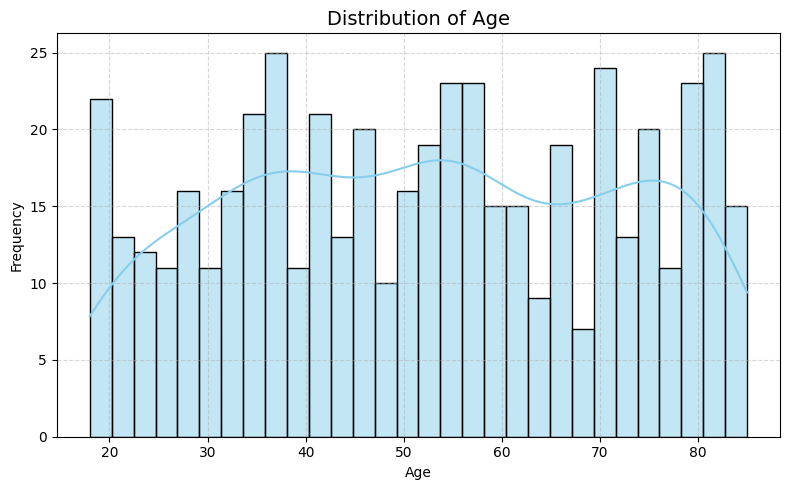

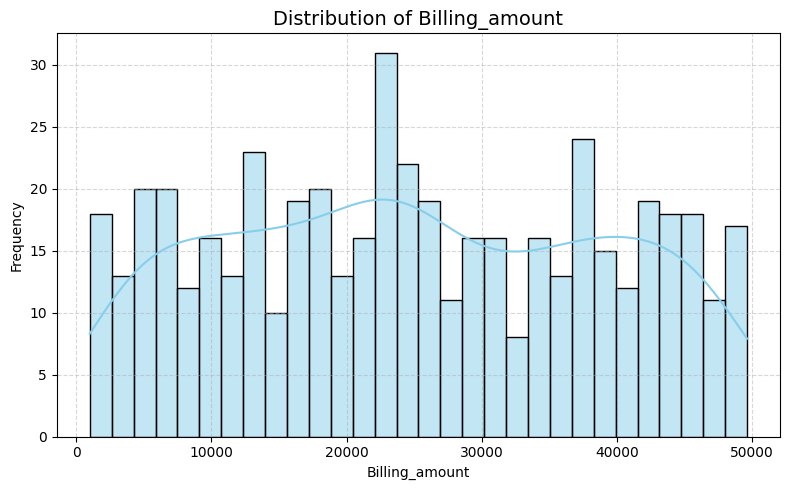

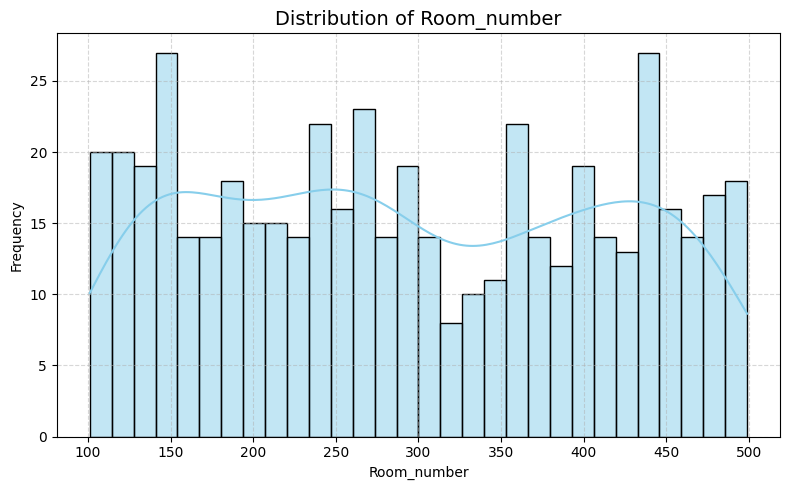

In [13]:
numerical_cols = df.select_dtypes(include='number').columns.tolist()

# Plot histograms for each numeric column
for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col.capitalize()}', fontsize=14)
    plt.xlabel(col.capitalize())
    plt.ylabel("Frequency")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()